In [1]:
import pandas as pd
import sklearn
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns



intnet_file = '/Users/mariaac/interaction/intnet_filled_devadd.txt'

interaction_network = pd.read_csv(intnet_file, sep='\t')
print('made table of data', flush=True)


target = 'lsb_123'

features_regressor = ['cos(phi)', 'halo_dists', 'relative_velocity', 'Nmajorint']


made table of data


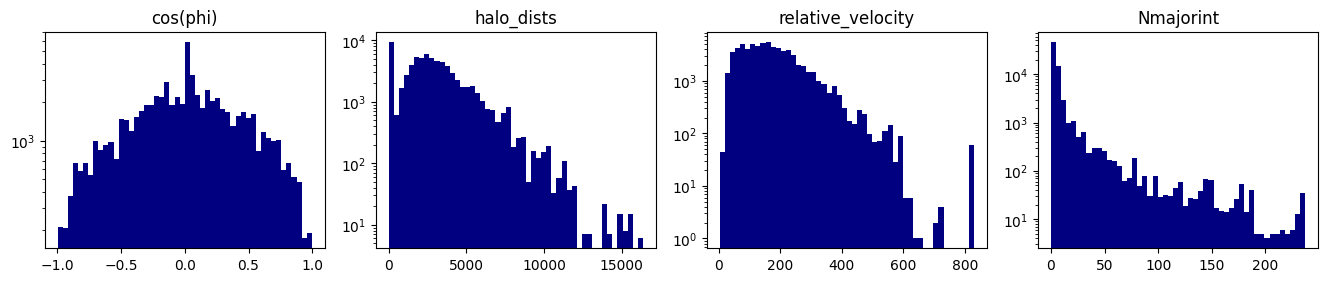

In [2]:
fig = plt.figure(0, [20, 18])

for k, feat in enumerate(features_regressor):
    ax = fig.add_subplot(7, 6, k+1)
    ax.hist(interaction_network[feat], bins=50, log=True, color='navy')
    ax.set_title(feat)

#ax = fig.add_subplot(7, 6, len(features_regressor)+1)
#ax.hist(interaction_network[target], bins=50, color='red')
#ax.set_title(r'$z_{\rm spec}$')

plt.tight_layout()
plt.show()

In [ ]:
X = interaction_network[features_regressor].values
y = interaction_network[target].values


from sklearn.preprocessing import StandardScaler
indices = np.arange(len(y))



X_train, X_validate, y_train, y_validate, indices_train, indices_validate = train_test_split(X, y, indices, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
X_validate_scaled = scaler.transform(X_validate)

model = LinearRegression()
model.fit(X_scaled, y_train)
y_pred_train = model.predict(X_scaled)

#y_pred = model.predict(X_validate_scaled)
n = X_scaled.shape[0]
p = X_scaled.shape[1]



residuals = y_train - y_pred_train
rss = np.sum(residuals**2)
mse = rss / (n - p - 1)

# Design matrix with intercept
X_design = np.column_stack([np.ones(n), X_scaled])

# Variance-covariance matrix of coefficients
cov_matrix = mse * np.linalg.inv(X_design.T @ X_design)
se = np.sqrt(np.diag(cov_matrix))

# t-statistics and p-values (coef 0 is intercept)
params = np.concatenate([[model.intercept_], model.coef_])
t_stats = params / se
p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=n - p - 1))

for name, coef, pval in zip(['intercept'] + features_regressor, params, p_values):
    print(f"{name}: p={pval:.4g}")

print("Coefficient (Slope):", model.coef_[0])
print("Intercept:", model.intercept_)


y_pred = model.predict(X_validate_scaled)
mae = mean_absolute_error(y_validate, y_pred)
mse = mean_squared_error(y_validate, y_pred)
r2 = r2_score(y_validate, y_pred)
print("MAE:", mae, "MSE:", mse, "R squared:", r2)